<a href="https://colab.research.google.com/github/corrielynnyuill-debug/AIProject_Stocks-CLY/blob/main/AIProject_Stocks_Part1_CLY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Mount drive in Colab
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
# Set file path
DATA_PATH = "/content/drive/MyDrive/AIProject/"

# load datasets to DataFrame
prices = pd.read_csv(DATA_PATH + 'historical_stock_prices.csv')
stocks = pd.read_csv(DATA_PATH + 'historical_stocks.csv')

# Basic EDA dataset structures
print('Historical Stock Prices Dataset\n')
print(prices.head())
print('-'*80)
print(prices.info())
print('-'*80)
print(prices.isnull().sum())
print('-'*80)
print(prices.describe())
print('-'*80)
print('Historical Stock Prices shape before manipulation')
print(prices.shape)
print('-'*80)
print('\nHistorical Stocks Dataset\n')
print(stocks.head())
print('-'*80)
print(stocks.info())
print('-'*80)
print(stocks.describe())
print('Historical Stocks shape before manipulation')
print(stocks.shape)
print('-'*80)

# Handle missing values
# Fill missing sector/industry per ticker using mode
stocks['sector'] = stocks.groupby('ticker')['sector'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else '_missing_'))
stocks['industry'] = stocks.groupby('ticker')['industry'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else '_missing_'))

# Fallback to exchange level mode
stocks['sector'] = stocks.groupby('exchange')['sector'].transform(
    lambda x: x.replace('_missing_',x.mode()[0] if not x.mode().empty else '_missing_'))
stocks['industry'] = stocks.groupby('exchange')['industry'].transform(
    lambda x: x.replace('_missing',x.mode()[0] if not x.mode().empty else '_missing_'))

# Final fallback
stocks['sector'] = stocks['sector'].replace('_missing_','Unknown')
stocks['industry'] = stocks['industry'].replace('_missing_','Unkown')

# Covert date column to datetime
prices['date'] = pd.to_datetime(prices['date'], errors='coerce')

# Check for conversion errors
print('Date conversion errors: ', prices['date'].isna().sum())
print('-'*80)

# Check for duplicates in HSP
dup_mask = prices.duplicated(subset=['ticker', 'date'])
print('Duplicate rows by ticker and date: ', dup_mask.sum())
print('-'*80)

# Drop duplicates
prices = prices[~dup_mask]

# Drop duplicates in HS
stocks = stocks[~stocks.duplicated(subset=['ticker'], keep='first')]

print('Historical Stock Prices shape after manipulation')
print(prices.shape)
print('-'*80)
print('Historical Stocks shape after manipulation')
print(stocks.shape)
print('-'*80)

# Set datetime index
prices = prices.set_index('date').sort_index()
print('Index type after', type(prices.index))
print('Index dtype', prices.index.dtype)
print('-'*80)

# Create decade column
prices['decade'] = (prices.index.year//10)*10
prices['decade'] = prices['decade'].astype(str) + 's'

# Segement while preserving DatetimeIndex
decades = {
    dec: prices[prices['decade'] == dec]
    for dec in sorted(prices['decade'].unique())
}
# Bring back date as column
prices_reset = prices.reset_index()

# Merge datasets
prices_merged = prices_reset.merge(
    stocks[['ticker', 'sector', 'industry']],
    on='ticker',
    how='left'
)
print(prices_merged.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Historical Stock Prices Dataset

  ticker   open  close  adj_close    low   high   volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400  2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100  2013-05-14
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date    

             open       high        low      close        volume
mean    12.491493  12.640192  12.366931  12.491549  7.248936e+05
median   2.791667   2.840909   2.765625   2.791667  1.872000e+05
std     46.981142  47.481931  46.513085  46.985360  1.377366e+06
--------------------------------------------------------------------------------
              open        high         low       close        volume
mean     16.814261   17.095074   16.561523   16.824845  8.375234e+05
median    5.000000    5.083333    4.958333    5.000000  6.460000e+04
std     573.048093  582.814179  562.257404  575.029287  4.510088e+06
--------------------------------------------------------------------------------
               open         high          low        close        volume
mean      45.291459    46.871896    43.814977    45.303495  8.635272e+05
median    10.583831    10.750000    10.437500    10.593750  6.220000e+04
std     1391.110191  1464.629619  1329.334616  1391.576526  5.834012e+06
----------

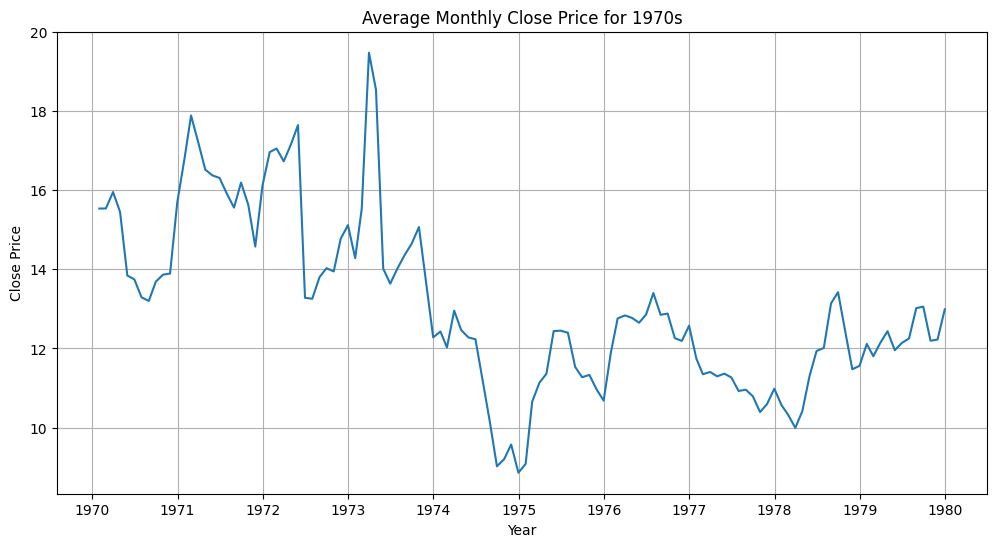

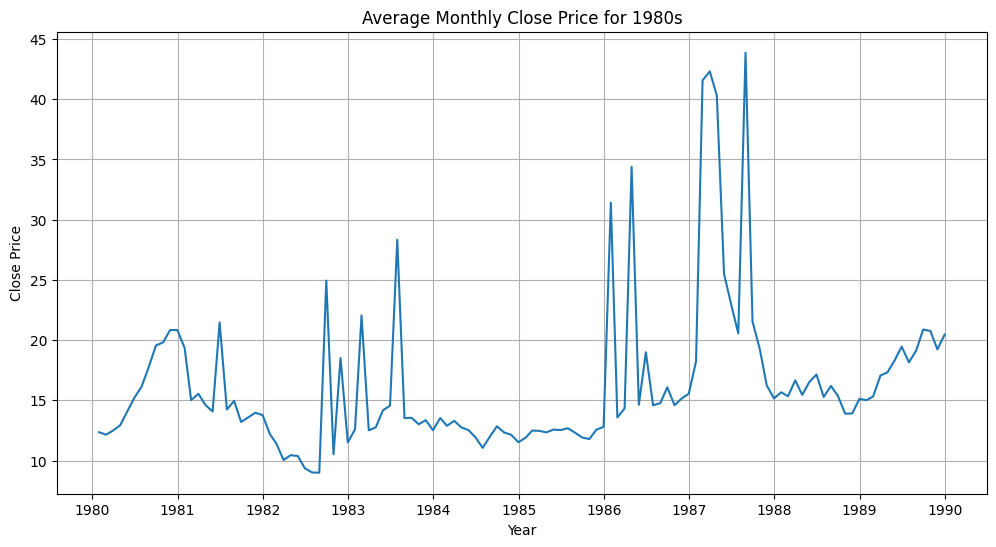

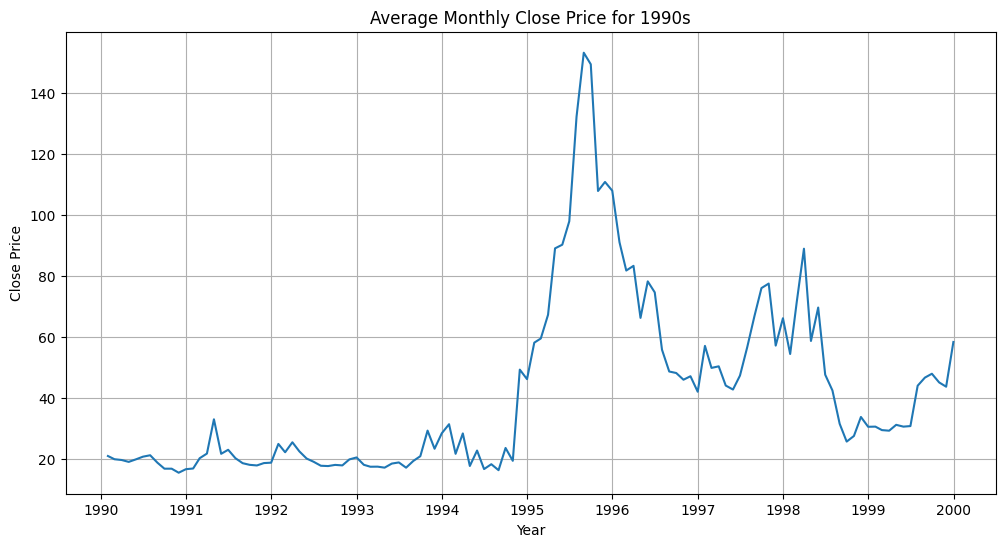

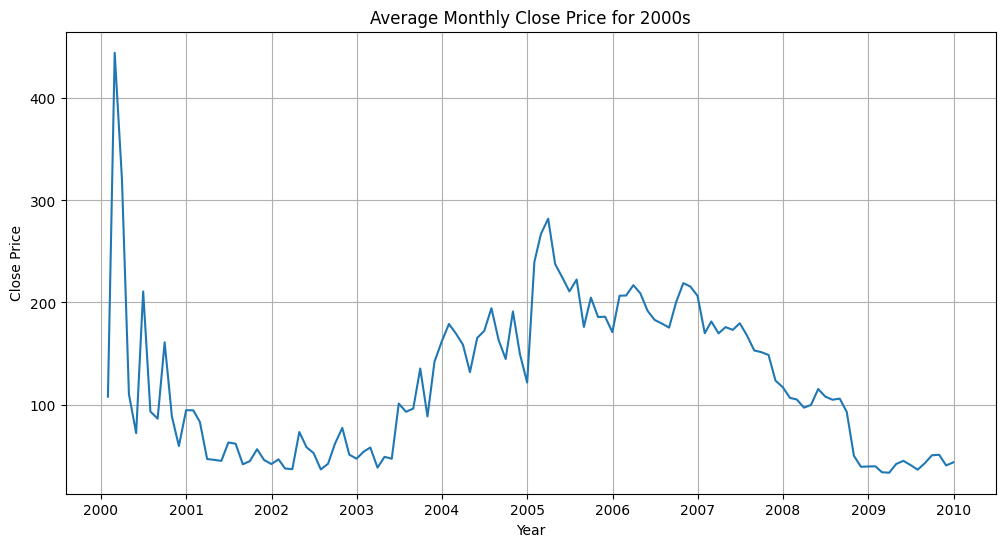

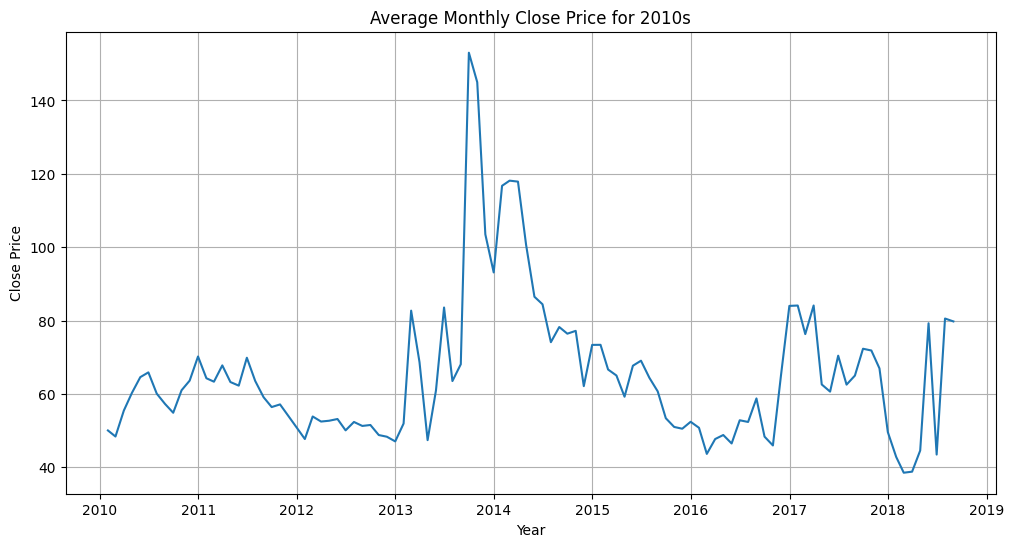

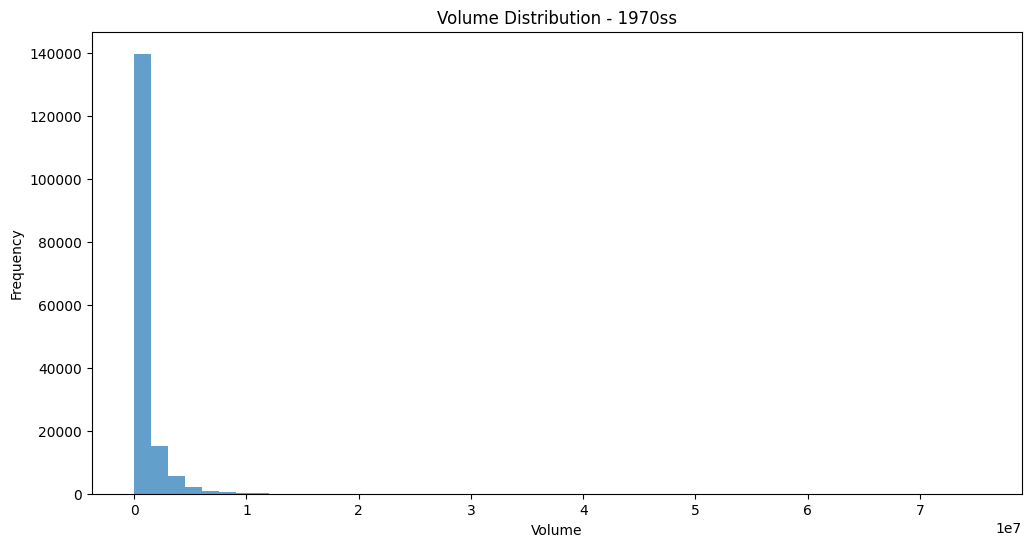

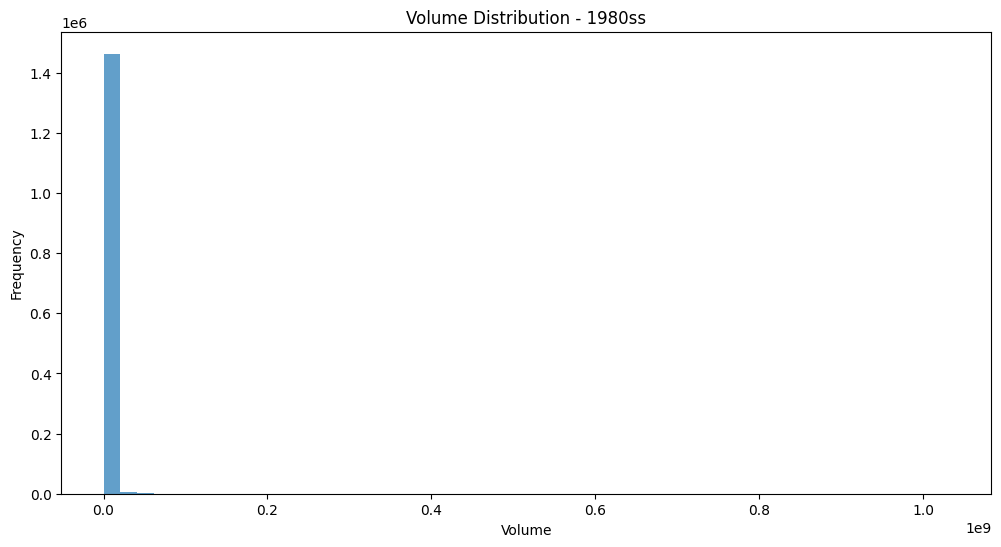

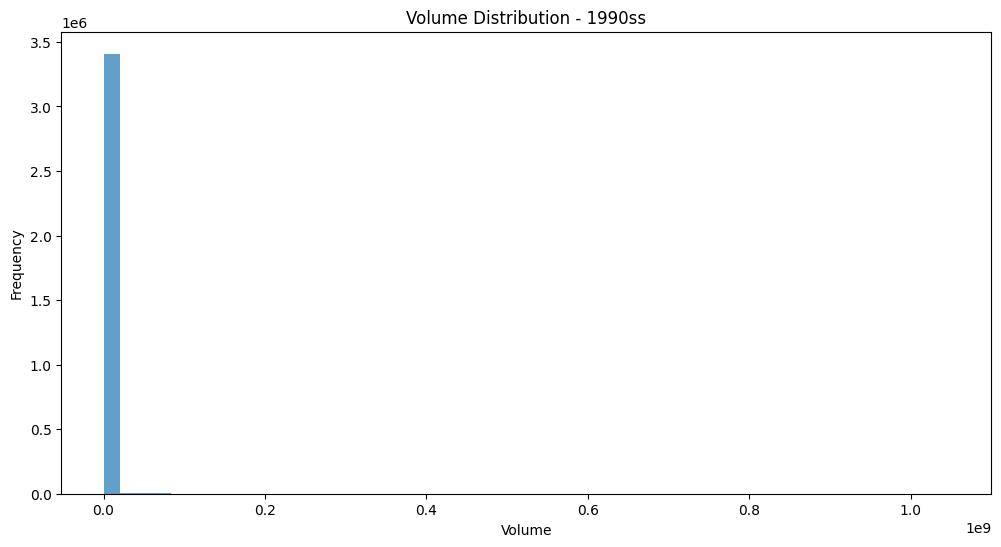

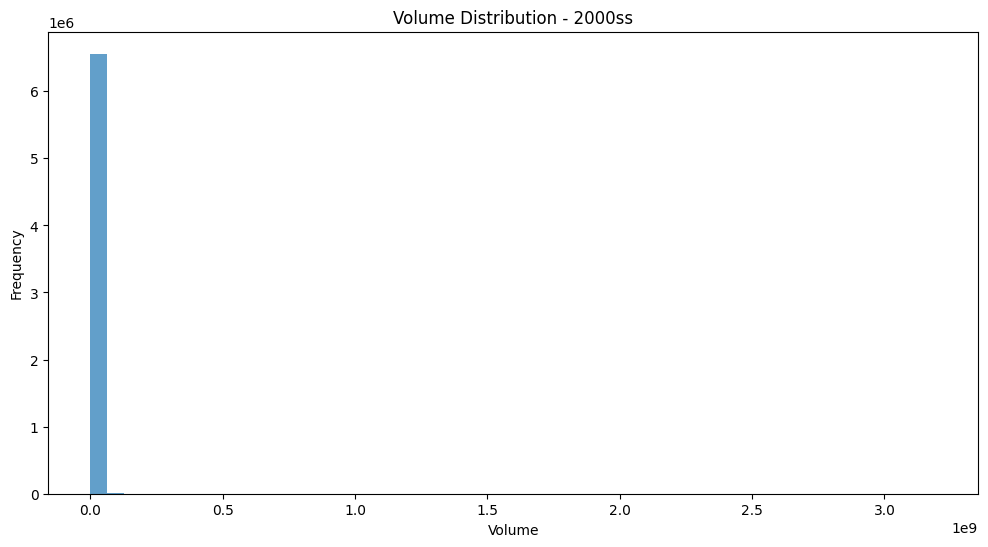

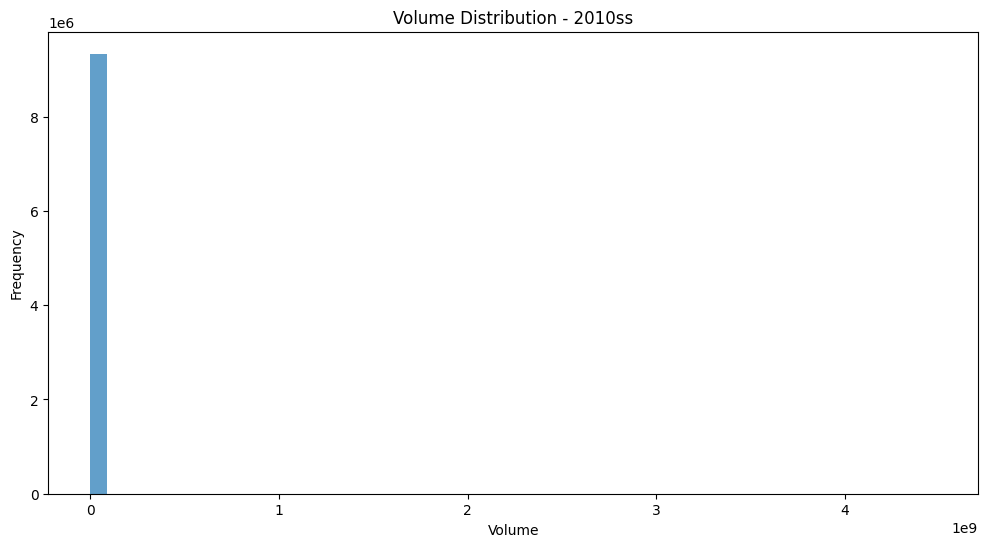

/tmp/ipykernel_21230/3664073470.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['High', 'Low'])


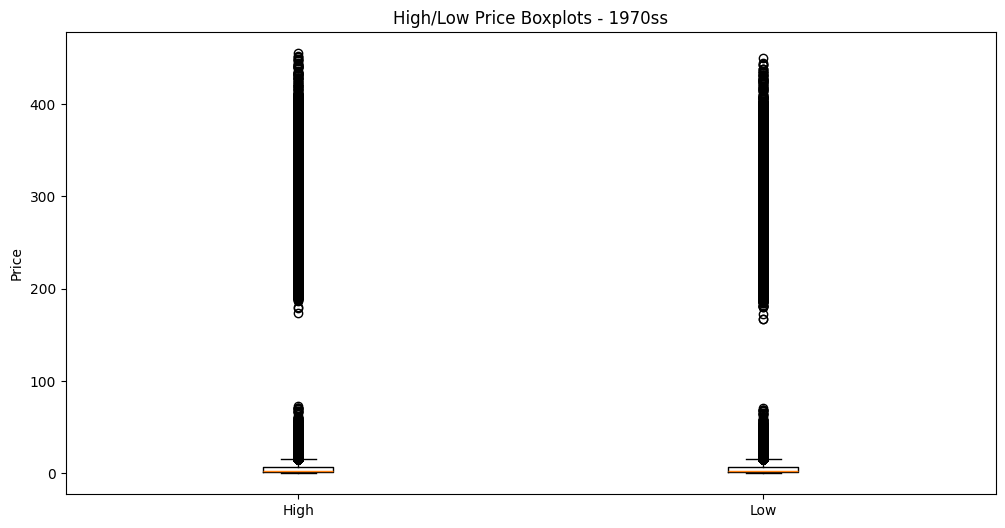

/tmp/ipykernel_21230/3664073470.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['High', 'Low'])


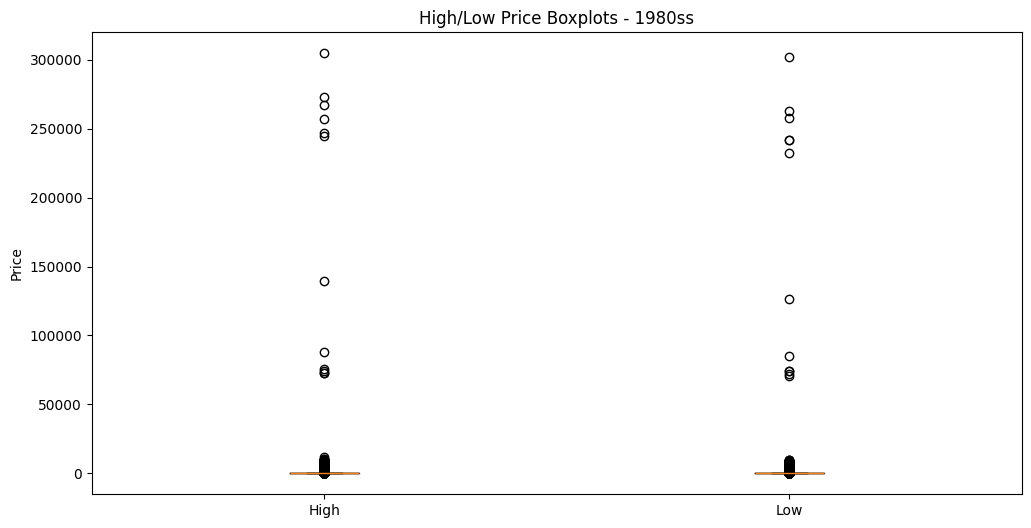

/tmp/ipykernel_21230/3664073470.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['High', 'Low'])


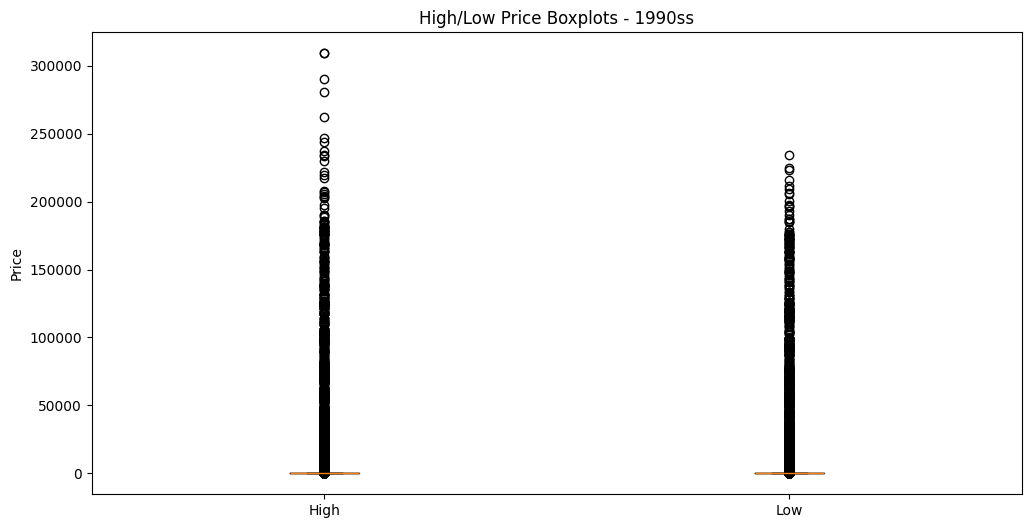

/tmp/ipykernel_21230/3664073470.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['High', 'Low'])


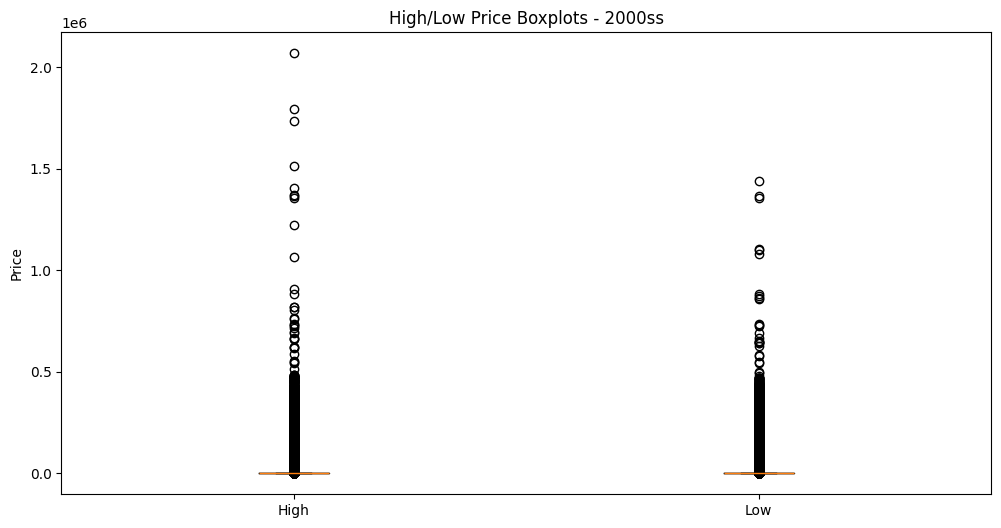

/tmp/ipykernel_21230/3664073470.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['High', 'Low'])


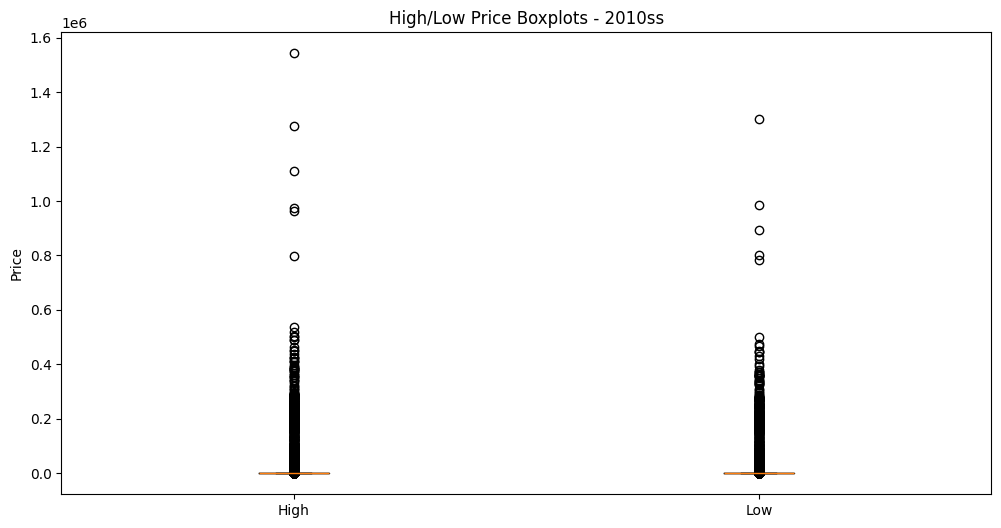

In [11]:
# Summary stats
summary_stats = {}
for dec, df in decades.items():
  summary_stats[dec] = df[['open', 'high', 'low', 'close', 'volume']].agg(
      ['mean', 'median', 'std']
  )
print(summary_stats['1970s'])
print('-'*80)
print(summary_stats['1980s'])
print('-'*80)
print(summary_stats['1990s'])
print('-'*80)
print(summary_stats['2000s'])
print('-'*80)
print(summary_stats['2010s'])
print('-'*80)
# Visualization 1 Average Monthly close
for dec, df in decades.items():
  monthly = df['close'].resample('ME').mean()
  plt.figure(figsize=(12, 6))
  plt.plot(monthly.index, monthly.values, label=f"{dec}s")
  plt.title(f'Average Monthly Close Price for {dec}')
  plt.xlabel('Year')
  plt.ylabel('Close Price')
  plt.grid(True)
  plt.show()

# Visualization 2 Volume Histogram
for dec, df in decades.items():
  plt.figure(figsize=(12, 6))
  plt.hist(df['volume'], bins=50, alpha=0.7, label=f"{dec}s")
  plt.title(f'Volume Distribution - {dec}s')
  plt.xlabel('Volume')
  plt.ylabel('Frequency')
  plt.show()

# Visualization 3 High/Low Boxplots
for dec, df in decades.items():
  plt.figure(figsize=(12, 6))
  plt.boxplot([df['high'], df['low']], labels=['High', 'Low'])
  plt.title(f'High/Low Price Boxplots - {dec}s')
  plt.ylabel('Price')
  plt.show()